In [125]:
from copy import deepcopy
import itertools
import json
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from pathlib import Path
import re
from scipy.ndimage import gaussian_filter1d
from scipy import stats
from scipy.special import huber
from scipy.optimize import minimize
import zipfile

In [2]:
# import saws
# import warms

In [126]:
PARAM_MAP = param_map = {
    "s1": 14562560,
    "s2": 32270848,
    "s3": 77124608,
    "s4": 134561280,
    "s5": 287183360,
    "s6": 610488320,
    "s7": 1217722368,
}


WIDTH_MAP = width_map = {
    "s0": 64,
    "s1": 128,
    "s2": 256,
    "s3": 512,
    "s4": 768,
    "s5": 1280,
    "s6": 2048,
    "s7": 3072,
}

In [127]:
WIDTH_PARAM_MAP = width_param_map = {
    "s1": 14562560,
    "s2": 32270848,
    "s3": 77124608,
    "s4": 134561280,
    "s5": 287183360,
    "s6": 610488320,
    "s7": 1217722368,
}

WIDTH_MAP = width_map = {
    "s0": 64,
    "s1": 128,
    "s2": 256,
    "s3": 512,
    "s4": 768,
    "s5": 1280,
    "s6": 2048,
    "s7": 3072,
}

In [4]:
def read_tb_parquet(path: Path, retain_cols: list[str] = None) -> pd.DataFrame:
    """ Read a completed run (TODO: read incomplete runs).
    """
    df = pd.read_parquet(path)
    if 2 in df.warmstart_stage.values:
        df.flops = df.flops - df.loc[df.warmstart_stage == 2].flops.values[0]
        df.tokens = df.tokens - df.loc[df.warmstart_stage == 2].tokens.values[0]
        df = df.loc[df.warmstart_stage > 1]
    if retain_cols is not None:
        df = df[retain_cols]
    return df

In [128]:
def gaussian_smooth(data, window_size):
    # Calculate the standard deviation for the Gaussian kernel
    sigma = window_size / 2.0
    
    # Apply Gaussian filter
    smoothed_data = gaussian_filter1d(data, sigma)
    
    return smoothed_data

In [129]:
def _parse_paths_for_meta_information(
    path: Path, 
    convert_scale_to_params: bool=True,
    param_map: dict[str, int]=WIDTH_PARAM_MAP,
) -> tuple[int, int, int, float]:
    """To parse the paths needed for the total learning curve set.
    """
    ## TODO: this function needs updating as and how more runs and thus paths are being processed

    k = str(path)
    # checking for token budget
    match = re.search(r'[0-9]\d*tkpm', str(k))
    D = float(match.group().split("tkpm")[0]) if match else 20.0

    # checking for parameter count
    ### check if a warmstarting path first
    is_ws = None
    _match = re.search(r's[1-9]\d*-s[1-9]\d*', str(k))
    if _match:
        base, target = _match.group().split("-")
        # NOTE: crucial flag
        is_ws = True if "/mup" not in k else False
    else:
        ### check if a scale is mentioned
        _match = re.search(r's[1-9]\d*', str(k))
        assert _match, f"No model scale information in the path: {k}"
        base = target = _match.group()

    # check for potential shrinking HP
    _match = re.search(r'shrinking=([0-9]*\.?[0-9]+)', str(k))
    if _match:
        lambda_shrink =float(_match.group().split("=")[-1])
    else:
        lambda_shrink = 0.4 if is_ws else 0

    if convert_scale_to_params:
        base = param_map[base]
        target = param_map[target]
    
    return D, base, target, lambda_shrink

In [130]:
# def get_pareto_frontier(df, col_name="Validation Loss"): 
#     """ Function to compute Pareto over FLOPs.
#     """
#     df_sorted = df.sort_values(by="flops")
#     pareto_points = []
#     min_loss_so_far = float('inf')
#     for _, row in df_sorted.iterrows():
#         if row[col_name] < min_loss_so_far:
#             pareto_points.append(row)
#             min_loss_so_far = row[col_name]

#     return pd.DataFrame(pareto_points)


def get_pareto_frontier(
    df: pd.DataFrame,
    x_name="flops",
    y_name="Validation Loss",
) -> pd.DataFrame: 
    """ Function to compute Pareto over FLOPs.
    """
    # NOTE: strict assumption here that x_name is maximized and y_name is minimized
    df_sorted = df.copy().sort_values(by=[x_name, y_name], ascending=[True, True])
    df_sorted = df_sorted.drop_duplicates(subset=[x_name], keep="first")
    pareto_points = []
    min_loss_so_far = float('inf')
    for _, row in df_sorted.iterrows():
        if row[y_name] < min_loss_so_far:
            pareto_points.append(row)
            min_loss_so_far = row[y_name]

    return pd.DataFrame(pareto_points)

---

In [131]:
BASE_DATA_PATH = Path("/work/dlclarge1/mallik-warmstarting/misc/neeratyoy/code/warmstarting_exps/playground/warmstart_runs_flattened.parquet")
# BASE_DATA_PATH = Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/playground/warmstart_runs_flattened.parquet")

In [132]:
full_df = pd.read_parquet(BASE_DATA_PATH)
display(full_df)

tag,tokens,flops,Train Loss,Validation Loss,tkpm,base_N,target_N,shrink,adam_beta_1,adam_beta_2,...,devices,weight_decay,seed,mup,n_layer,n_embd,n_head,warmstart_type,method,shrinking
0,0,0.000000e+00,10.957504,10.984583,10.0,14562560,32270848,0.2,0.9,0.95,...,2,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2
1,65536,1.268941e+13,11.012417,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,2,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2
2,131072,2.537883e+13,10.583125,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,2,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2
3,196608,3.806824e+13,9.702733,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,2,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2
4,262144,5.075766e+13,8.710074,NaN,10.0,14562560,32270848,0.2,0.9,0.95,...,2,0,666,True,8,256,4,snp_zeros_with_mup,paws,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2293983,2868977664,4.943536e+18,1.666541,NaN,10.0,77124608,287183360,0.4,0.9,0.95,...,4,0,666,True,8,1280,20,net2net,net2net,NaN
2293984,2869493760,4.944425e+18,1.636161,NaN,10.0,77124608,287183360,0.4,0.9,0.95,...,4,0,666,True,8,1280,20,net2net,net2net,NaN
2293985,2870009856,4.945314e+18,1.750974,NaN,10.0,77124608,287183360,0.4,0.9,0.95,...,4,0,666,True,8,1280,20,net2net,net2net,NaN
2293986,2870525952,4.946204e+18,1.739581,NaN,10.0,77124608,287183360,0.4,0.9,0.95,...,4,0,666,True,8,1280,20,net2net,net2net,NaN


In [133]:
full_df.method.unique()

array(['paws', 'mup', 'net2net'], dtype=object)

In [134]:
_mup = full_df.loc[full_df.method == "mup"]
_no_shrink = full_df.loc[full_df.shrink == 0.0]

print(_mup.shape, _no_shrink.shape)

(331769, 31) (331769, 31)


In [121]:
# NOTE: selecting the smallest base model for comparison

_base = int(_mup.base_N.min())  

BASE_LOSS = 2.4956164360046387  # s1 (width=64) at 20 tkpm with no warmstarting

_targets = _mup.target_N.unique().tolist()
# _tkpms = sorted(_mup.tkpm.unique().tolist())
_tkpms = [10.0, 20.0, 30.0]
data_map = {}
for _target in _targets:
    data_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        data_map[_target][_tkpm] = dict()
        plot_df = _df.groupby("shrink")["Validation Loss"].min()
        data_map[_target][_tkpm] = plot_df.to_dict()

In [ ]:
# https://docs.google.com/document/d/1iGzrncBSsESnCYq0k3Mx-4_gJNkLGVJpgDUKU7SckG0/edit?tab=t.bkzw7e7mv1e1

<Figure size 640x480 with 0 Axes>

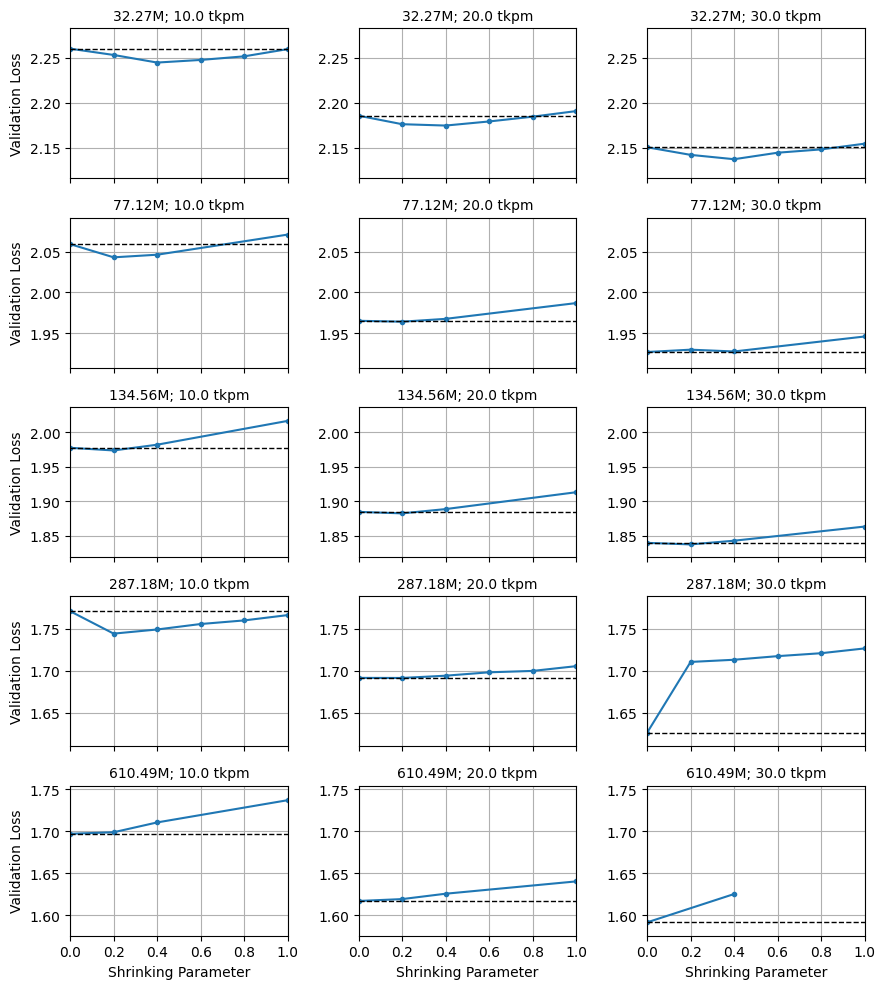

In [122]:
plt.clf()
fig, axes = plt.subplots(len(data_map), 3, figsize=(9, 2 * len(data_map)), squeeze=False, sharex=True)

# for row_id, (_key, _scale_map) in enumerate(data_map.items()):
for row_id, _key in enumerate(sorted(data_map.keys())):
    _scale_map = data_map[_key]
    _ylims = []
    for col_id, (__key, _shrink_map) in enumerate(_scale_map.items()):
        try:
            ax = axes[row_id][col_id]
        except:
            continue
        shrinks = sorted(_shrink_map.keys())
        losses = [_shrink_map[s] for s in shrinks]
        ax.plot(shrinks, losses, marker='o', markersize=3)
        if 0 in _shrink_map:
            ax.hlines(_shrink_map[0], xmin=0, xmax=1, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{_key/1e6:.2f}M; {__key} tkpm", fontsize=10)
        if row_id == len(data_map) - 1:
            ax.set_xlabel("Shrinking Parameter")
        ax.grid(True)
        # ax.set_ylim(1.5, 2.3)
        # ax.set_yscale("log")
        ax.set_xlim(0, 1)
        _ylims.extend(losses)
    axes[row_id, 0].set_ylabel("Validation Loss")
    if not _ylims: continue
    for col_id in range(len(_scale_map)):
        axes[row_id, col_id].set_ylim(min(_ylims) * 0.99, max(_ylims) * 1.01)

plt.tight_layout()

selecting base model with 32270848 params


<Figure size 640x480 with 0 Axes>

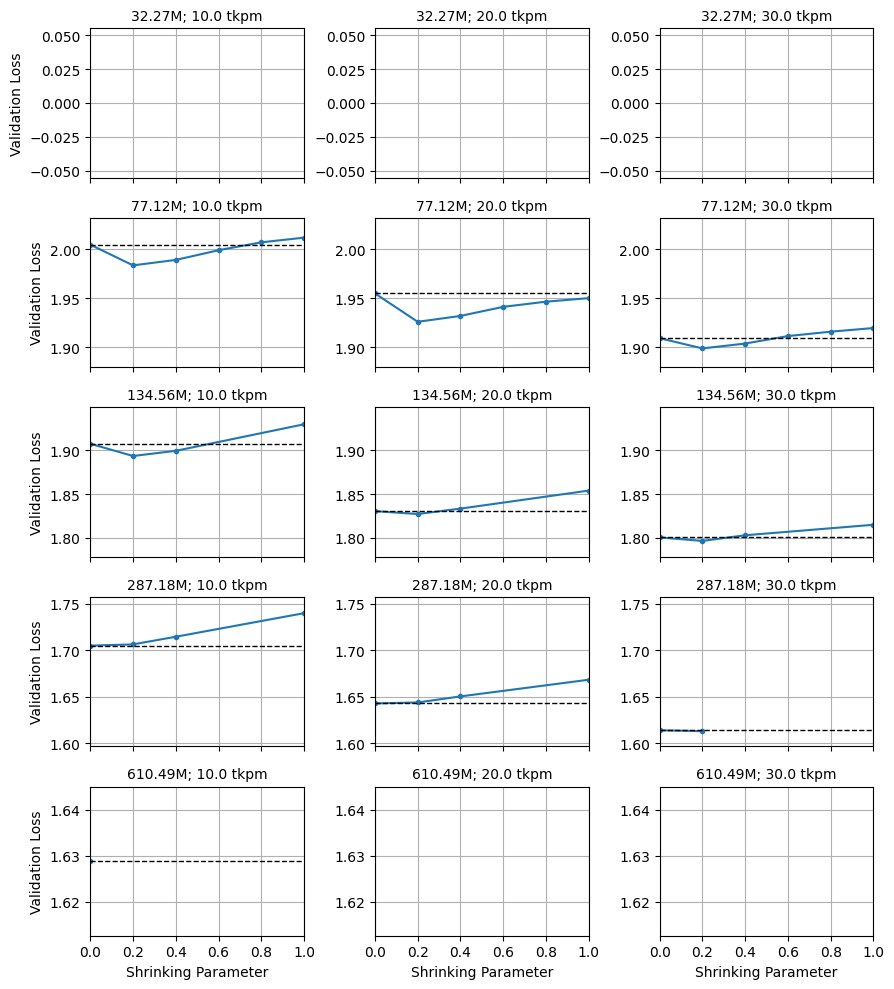

In [123]:
# NOTE: selecting the second smallest base model for comparison

_base = int(sorted(_mup.base_N.unique())[1])
print(f"selecting base model with {_base} params")
# BASE_LOSS = 2.4956164360046387  # s1 (width=64) at 20 tkpm with no warmstarting
BASE_LOSS = 2.1947426795959473  # s2 
# BASE_LOSS = 1.9329144954681396  # s3

_targets = _mup.target_N.unique().tolist()
# _tkpms = sorted(_mup.tkpm.unique().tolist())
_tkpms = [10.0, 20.0, 30.0]
data_map = {}
for _target in _targets:
    data_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        data_map[_target][_tkpm] = dict()
        plot_df = _df.groupby("shrink")["Validation Loss"].min()
        data_map[_target][_tkpm] = plot_df.to_dict()

plt.clf()
fig, axes = plt.subplots(len(data_map), 3, figsize=(9, 2 * len(data_map)), squeeze=False, sharex=True)

# for row_id, (_key, _scale_map) in enumerate(data_map.items()):
for row_id, _key in enumerate(sorted(data_map.keys())):
    _scale_map = data_map[_key]
    _ylims = []
    for col_id, (__key, _shrink_map) in enumerate(_scale_map.items()):
        try:
            ax = axes[row_id][col_id]
        except:
            continue
        shrinks = sorted(_shrink_map.keys())
        losses = [_shrink_map[s] for s in shrinks]
        ax.plot(shrinks, losses, marker='o', markersize=3)
        if 0 in _shrink_map:
            ax.hlines(_shrink_map[0], xmin=0, xmax=1, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{_key/1e6:.2f}M; {__key} tkpm", fontsize=10)
        if row_id == len(data_map) - 1:
            ax.set_xlabel("Shrinking Parameter")
        ax.grid(True)
        # ax.set_ylim(1.5, 2.3)
        # ax.set_yscale("log")
        ax.set_xlim(0, 1)
        _ylims.extend(losses)
    axes[row_id, 0].set_ylabel("Validation Loss")
    if not _ylims: continue
    for col_id in range(len(_scale_map)):
        axes[row_id, col_id].set_ylim(min(_ylims) * 0.99, max(_ylims) * 1.01)

plt.tight_layout()

selecting base model with 77124608 params


<Figure size 640x480 with 0 Axes>

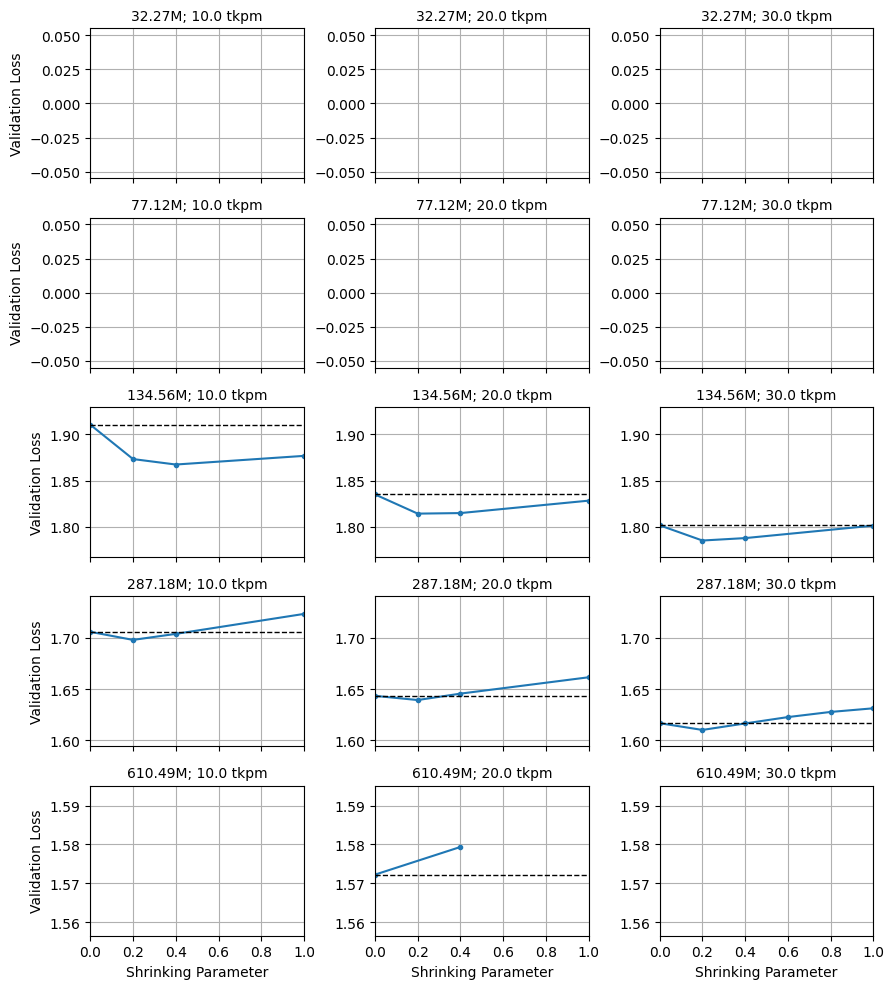

In [124]:
# NOTE: selecting the second smallest base model for comparison

_base = int(sorted(_mup.base_N.unique())[2])
print(f"selecting base model with {_base} params")
# BASE_LOSS = 2.4956164360046387  # s1 (width=64) at 20 tkpm with no warmstarting
# BASE_LOSS = 2.1947426795959473  # s2 
BASE_LOSS = 1.9329144954681396  # s3

_targets = _mup.target_N.unique().tolist()
# _tkpms = sorted(_mup.tkpm.unique().tolist())
_tkpms = [10.0, 20.0, 30.0]
data_map = {}
for _target in _targets:
    data_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        data_map[_target][_tkpm] = dict()
        plot_df = _df.groupby("shrink")["Validation Loss"].min()
        data_map[_target][_tkpm] = plot_df.to_dict()

plt.clf()
fig, axes = plt.subplots(len(data_map), 3, figsize=(9, 2 * len(data_map)), squeeze=False, sharex=True)

# for row_id, (_key, _scale_map) in enumerate(data_map.items()):
for row_id, _key in enumerate(sorted(data_map.keys())):
    _scale_map = data_map[_key]
    _ylims = []
    for col_id, (__key, _shrink_map) in enumerate(_scale_map.items()):
        try:
            ax = axes[row_id][col_id]
        except:
            continue
        shrinks = sorted(_shrink_map.keys())
        losses = [_shrink_map[s] for s in shrinks]
        ax.plot(shrinks, losses, marker='o', markersize=3)
        if 0 in _shrink_map:
            ax.hlines(_shrink_map[0], xmin=0, xmax=1, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{_key/1e6:.2f}M; {__key} tkpm", fontsize=10)
        if row_id == len(data_map) - 1:
            ax.set_xlabel("Shrinking Parameter")
        ax.grid(True)
        # ax.set_ylim(1.5, 2.3)
        # ax.set_yscale("log")
        ax.set_xlim(0, 1)
        _ylims.extend(losses)
    axes[row_id, 0].set_ylabel("Validation Loss")
    if not _ylims: continue
    for col_id in range(len(_scale_map)):
        axes[row_id, col_id].set_ylim(min(_ylims) * 0.99, max(_ylims) * 1.01)

plt.tight_layout()

In [600]:
# mapping the difference in loss between mup and no shrink (lambda=1)
## for each target scale-tkpm, given the smallest base scale, 
## create a dict with the value as the loss difference between lambda=1.0 and mup (lambda=0.0)

loss_diff_map = {}
for _target in _targets:
    loss_diff_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        if len(_df) == 0:
            continue
        mup_loss = _df.loc[_df.method == "mup"]["Validation Loss"].min()
        no_shrink_loss = _df.loc[_df.shrink == 1.0]["Validation Loss"].min()
        if pd.isna(mup_loss) or pd.isna(no_shrink_loss):
            continue
        loss_diff_map[_target][_tkpm] = mup_loss - no_shrink_loss

Text(0, 0.5, 'Loss Difference (mup - no shrink)')

<Figure size 432x288 with 0 Axes>

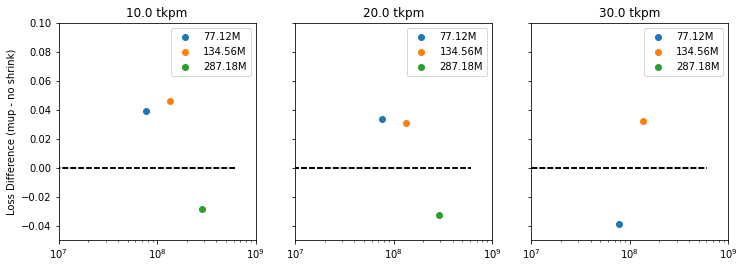

In [601]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False, sharey=True)
for i, k in enumerate(sorted(loss_diff_map.keys())):
    for j, tkpm in enumerate(sorted(loss_diff_map[k].keys())):
        ax = axes[0][j]
        ax.set_title(f"{tkpm} tkpm")
        ax.scatter(k, loss_diff_map[k][tkpm], label=f"{k/1e6:.2f}M")
        ax.set_xscale("log")
        ax.set_xlim(1e7, 1e9)
        ax.set_ylim(-0.05, 0.1)
        ax.legend()
        axes[0, j].hlines(
            0, xmin=0, xmax=max(list(loss_diff_map.keys())), 
            colors='r', linestyles='dashed', color="black"
        )
axes[0, 0].set_ylabel("Loss Difference (mup - no shrink)", fontsize=10)

Text(0, 0.5, 'Loss Difference (mup - no shrink)')

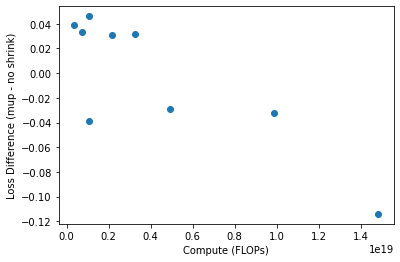

In [602]:
new_dict = dict()
for param, param_dict in loss_diff_map.items():
    for token, token_dict in param_dict.items():
        new_dict[6 * param * token * param] = token_dict

plt.clf()
plt.scatter(
    sorted(new_dict.keys()), 
    [new_dict[k] for k in sorted(new_dict.keys())], 
    marker='o'
)
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Loss Difference (mup - no shrink)")
# plt.yscale("log")
# plt.xscale("log")

In [604]:
# mapping the difference in loss between 0.2 shrink and no shrink (lambda=1)
## for each target scale-tkpm, given the smallest base scale, create a dict with 
## the value as the loss difference between lambda=1.0 and lambda=0.2 (lowest available shrinking)

loss_diff_map = {}
for _target in _targets:
    loss_diff_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        if len(_df) == 0:
            continue
        low_shrink_loss = _df.loc[_df.shrink == 0.2]["Validation Loss"].min()
        no_shrink_loss = _df.loc[_df.shrink == 1.0]["Validation Loss"].min()
        if pd.isna(low_shrink_loss) or pd.isna(no_shrink_loss):
            continue
        loss_diff_map[_target][_tkpm] = no_shrink_loss - low_shrink_loss



Text(0, 0.5, 'Loss Difference (0.2 shrink - no shrink)')

<Figure size 432x288 with 0 Axes>

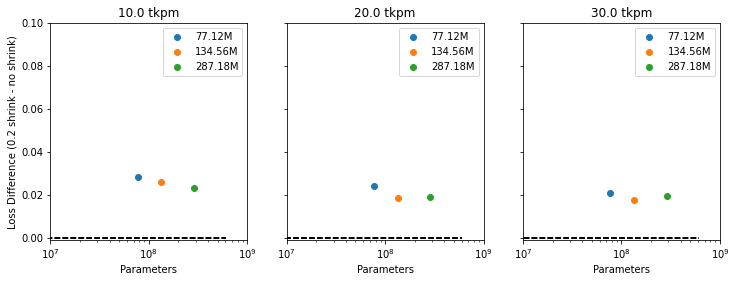

In [605]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False, sharey=True)
for i, k in enumerate(sorted(loss_diff_map.keys())):
    for j, tkpm in enumerate(sorted(loss_diff_map[k].keys())):
        ax = axes[0][j]
        ax.set_title(f"{tkpm} tkpm")
        ax.scatter(k, loss_diff_map[k][tkpm], label=f"{k/1e6:.2f}M")
        ax.legend(loc="upper right")
        axes[0, j].hlines(
            0, xmin=0, xmax=max(list(loss_diff_map.keys())), 
            colors='r', linestyles='dashed', color="black"
        )
        ax.set_xscale("log")
        ax.set_xlim(1e7, 1e9)
        ax.set_ylim(-0.001, 0.1)
        ax.set_xlabel("Parameters")
axes[0, 0].set_ylabel("Loss Difference (0.2 shrink - no shrink)", fontsize=10)

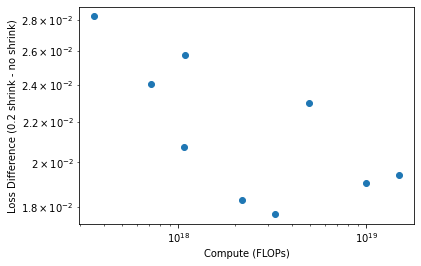

In [606]:
new_dict = dict()
for param, param_dict in loss_diff_map.items():
    for token, token_dict in param_dict.items():
        new_dict[6 * param * token * param] = token_dict

plt.clf()
plt.scatter(
    sorted(new_dict.keys()), 
    [new_dict[k] for k in sorted(new_dict.keys())], 
    marker='o'
)
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Loss Difference (0.2 shrink - no shrink)")
plt.yscale("log")
plt.xscale("log")

In [608]:
# mapping the difference in loss between 0.8 shrink and no shrink (lambda=1)
## for each target scale-tkpm, given the smallest base scale, create a dict with 
## the value as the loss difference between lambda=1.0 and lambda=0.8

loss_diff_map = {}
for _target in _targets:
    loss_diff_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        if len(_df) == 0:
            continue
        low_shrink_loss = _df.loc[_df.shrink == 0.8]["Validation Loss"].min()
        no_shrink_loss = _df.loc[_df.shrink == 1.0]["Validation Loss"].min()
        if pd.isna(low_shrink_loss) or pd.isna(no_shrink_loss):
            continue
        loss_diff_map[_target][_tkpm] = no_shrink_loss - low_shrink_loss



Text(0, 0.5, 'Loss Difference (0.8 shrink - no shrink)')

<Figure size 432x288 with 0 Axes>

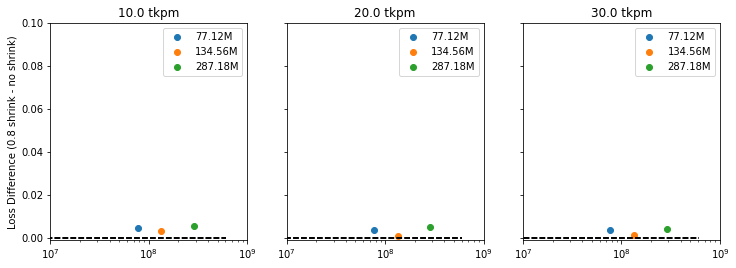

In [611]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False, sharey=True)
for i, k in enumerate(sorted(loss_diff_map.keys())):
    for j, tkpm in enumerate(sorted(loss_diff_map[k].keys())):
        ax = axes[0][j]
        ax.set_title(f"{tkpm} tkpm")
        ax.scatter(k, loss_diff_map[k][tkpm], label=f"{k/1e6:.2f}M")
        ax.legend(loc="upper right")
        axes[0, j].hlines(
            0, xmin=0, xmax=max(list(loss_diff_map.keys())), 
            colors='r', linestyles='dashed', color="black"
        )
        ax.set_xscale("log")
        ax.set_xlim(1e7, 1e9)
        ax.set_ylim(-0.001, 0.1)
        # ax.set_yscale("log")
axes[0, 0].set_ylabel("Loss Difference (0.8 shrink - no shrink)", fontsize=10)

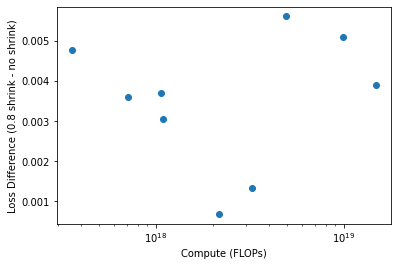

In [612]:
new_dict = dict()
for param, param_dict in loss_diff_map.items():
    for token, token_dict in param_dict.items():
        new_dict[6 * param * token * param] = token_dict

plt.clf()
plt.scatter(
    sorted(new_dict.keys()), 
    [new_dict[k] for k in sorted(new_dict.keys())], 
    marker='o'
)
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Loss Difference (0.8 shrink - no shrink)")
# plt.yscale("log")
plt.xscale("log")

In [613]:
# mapping the difference in loss between mup and low shrink (lambda=0.2)
## for each target scale-tkpm, given the smallest base scale, 
## create a dict with the value as the loss difference between lambda=0.2 and mup (lambda=0.0)

loss_diff_map = {}
for _target in _targets:
    loss_diff_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        if len(_df) == 0:
            continue
        mup_loss = _df.loc[_df.method == "mup"]["Validation Loss"].min()
        no_shrink_loss = _df.loc[_df.shrink == 0.2]["Validation Loss"].min()
        if pd.isna(mup_loss) or pd.isna(no_shrink_loss):
            continue
        loss_diff_map[_target][_tkpm] = mup_loss - no_shrink_loss

Text(0, 0.5, 'Loss Difference (mup - 0.2 shrink)')

<Figure size 432x288 with 0 Axes>

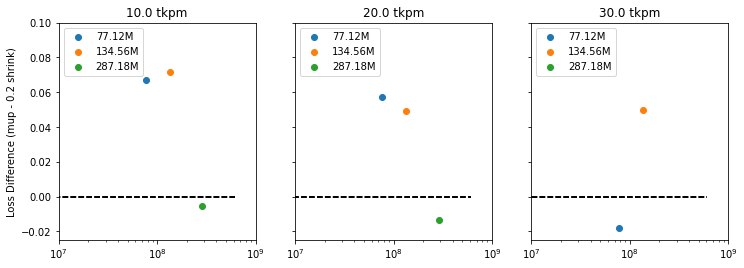

In [614]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False, sharey=True)
for i, k in enumerate(sorted(loss_diff_map.keys())):
    for j, tkpm in enumerate(sorted(loss_diff_map[k].keys())):
        ax = axes[0][j]
        ax.set_title(f"{tkpm} tkpm")
        ax.scatter(k, loss_diff_map[k][tkpm], label=f"{k/1e6:.2f}M")
        ax.legend(loc="upper left")
        axes[0, j].hlines(
            0, xmin=0, xmax=max(list(loss_diff_map.keys())), 
            colors='r', linestyles='dashed', color="black"
        )
        ax.set_xscale("log")
        ax.set_xlim(1e7, 1e9)
        ax.set_ylim(-0.025, 0.1)
        # ax.set_yscale("log")
axes[0, 0].set_ylabel("Loss Difference (mup - 0.2 shrink)", fontsize=10)

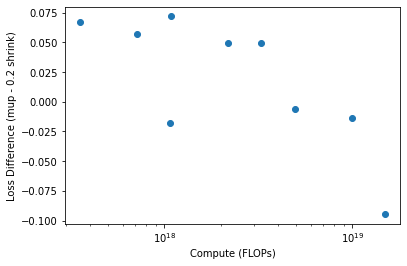

In [615]:
new_dict = dict()
for param, param_dict in loss_diff_map.items():
    for token, token_dict in param_dict.items():
        new_dict[6 * param * token * param] = token_dict

plt.clf()
plt.scatter(
    sorted(new_dict.keys()), 
    [new_dict[k] for k in sorted(new_dict.keys())], 
    marker='o'
)
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Loss Difference (mup - 0.2 shrink)")
# plt.yscale("log")
plt.xscale("log")

In [616]:
## for each target scale-tkpm, given the smallest base scale, create a table with 
## the lowest loss seen and the corresponding shrink value (ignoring shrink=0 completely)

table_map = {}
for _target in _targets:
    table_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm) &
            (full_df.shrink != 0.0)
        ]
        if len(_df) == 0:
            continue
        min_row = _df.loc[_df["Validation Loss"].idxmin()]
        table_map[_target][_tkpm] = {
            "shrink": min_row.shrink,
            "val_loss": min_row["Validation Loss"]
        }


Text(0, 0.5, 'Validation Loss')

<Figure size 432x288 with 0 Axes>

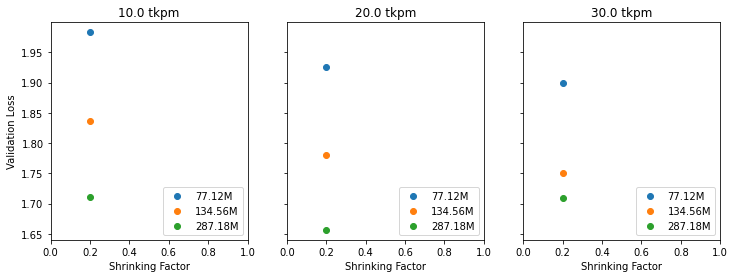

In [617]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False, sharey=True)
for i, k in enumerate(sorted(table_map.keys())):
    for j, tkpm in enumerate(sorted(table_map[k].keys())):
        ax = axes[0][j]
        ax.set_title(f"{tkpm} tkpm")
        ax.scatter(
            table_map[k][tkpm]["shrink"], table_map[k][tkpm]["val_loss"], 
            label=f"{k/1e6:.2f}M"
        )
        ax.legend(loc="lower right")
        ax.set_xlim(0, 1)
        ax.set_xlabel("Shrinking Factor")
axes[0, 0].set_ylabel("Validation Loss", fontsize=10)

/tmp/ipykernel_2230329/2687151264.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('plasma', len(_shrinks))


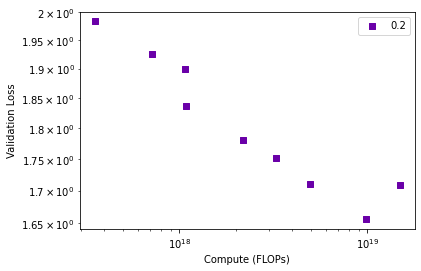

In [618]:
new_dict = dict()
for param, param_dict in table_map.items():
    for token, token_dict in param_dict.items():
        new_dict[6 * param * token * param] = token_dict

plt.clf()
_shrinks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
_markers = ['o', 's', '^', 'D', 'v', 'P']
color_map = cm.get_cmap('plasma', len(_shrinks))
for k, v in new_dict.items():
    plt.scatter(
        k, v["val_loss"], color=color_map(_shrinks.index(v['shrink'])), label=f"{v['shrink']}",
        marker=_markers[_shrinks.index(v['shrink'])]
    )

handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Validation Loss")
plt.yscale("log")
plt.xscale("log")

In [619]:
# mapping the difference in loss between mup and base loss
## for each target scale-tkpm, given the smallest base scale, 
## create a dict with the value as the loss difference between lambda=0.2 and mup (lambda=0.0)

loss_diff_map = {}

for _target in _targets:
    loss_diff_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm) & 
            (full_df.method == "mup")
        ]
        if len(_df) == 0:
            continue
        mup_loss = _df["Validation Loss"].min()
        if pd.isna(mup_loss):
            continue
        loss_diff_map[_target][_tkpm] = BASE_LOSS - mup_loss

Text(0, 0.5, 'Loss Difference (base loss - mup target)')

<Figure size 432x288 with 0 Axes>

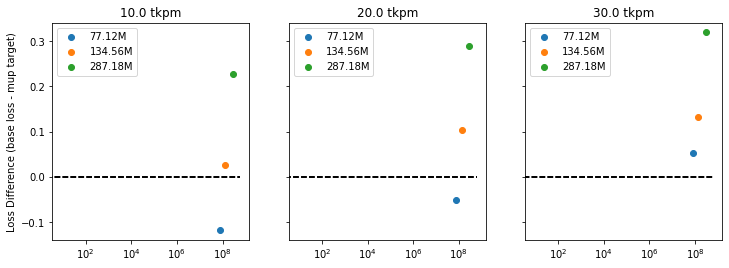

In [621]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False, sharey=True)
for i, k in enumerate(sorted(loss_diff_map.keys())):
    for j, tkpm in enumerate(sorted(loss_diff_map[k].keys())):
        ax = axes[0][j]
        ax.set_title(f"{tkpm} tkpm")
        ax.scatter(k, loss_diff_map[k][tkpm], label=f"{k/1e6:.2f}M")
        ax.legend(loc="upper left")
        axes[0, j].hlines(
            0, xmin=0, xmax=max(list(loss_diff_map.keys())), 
            colors='r', linestyles='dashed', color="black"
        )
        ax.set_xscale("log")
        # ax.set_xlim(1e7, 1e9)
        # ax.set_ylim(-0.001, 0.1)
        # ax.set_yscale("log")
axes[0, 0].set_ylabel("Loss Difference (base loss - mup target)", fontsize=10)

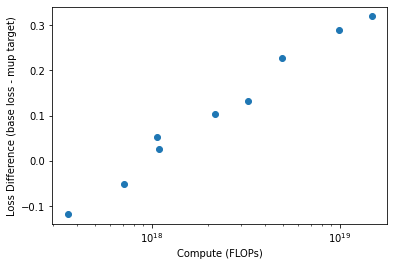

In [622]:
new_dict = dict()
for param, param_dict in loss_diff_map.items():
    for token, token_dict in param_dict.items():
        new_dict[6 * param * token * param] = token_dict

plt.clf()
plt.scatter(
    sorted(new_dict.keys()), 
    [new_dict[k] for k in sorted(new_dict.keys())], 
    marker='o'
)
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Loss Difference (base loss - mup target)")
# plt.yscale("log")
plt.xscale("log")

In [623]:
# mapping the difference in loss between no-shrink and base loss
## for each target scale-tkpm, given the smallest base scale, 
## create a dict with the value as the loss difference between lambda=1.0 and mup (lambda=0.0)

loss_diff_map = {}

for _target in _targets:
    loss_diff_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        if len(_df) == 0:
            continue
        _loss = _df.loc[_df.shrink == 1.0]["Validation Loss"].min()
        if pd.isna(_loss):
            continue
        loss_diff_map[_target][_tkpm] = BASE_LOSS - _loss

Text(0, 0.5, 'Loss Difference (base loss - no shrink)')

<Figure size 432x288 with 0 Axes>

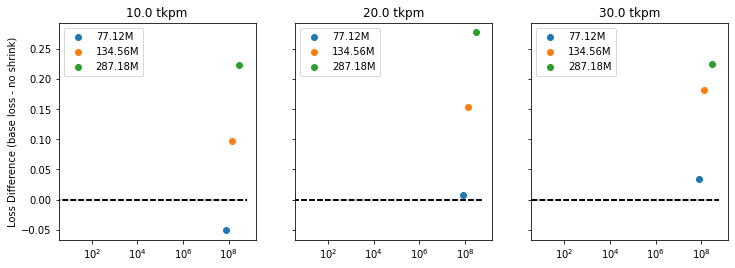

In [629]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False, sharey=True)
for i, k in enumerate(sorted(loss_diff_map.keys())):
    for j, tkpm in enumerate(sorted(loss_diff_map[k].keys())):
        ax = axes[0][j]
        ax.set_title(f"{tkpm} tkpm")
        ax.scatter(k, loss_diff_map[k][tkpm], label=f"{k/1e6:.2f}M")
        ax.legend(loc="upper left")
        axes[0, j].hlines(
            0, xmin=0, xmax=max(list(loss_diff_map.keys())), 
            colors='r', linestyles='dashed', color="black"
        )
        ax.set_xscale("log")
        # ax.set_xlim(1e7, 1e9)
        # ax.set_ylim(-0.001, 0.1)
        # ax.set_yscale("log")
axes[0, 0].set_ylabel("Loss Difference (base loss - no shrink)", fontsize=10)

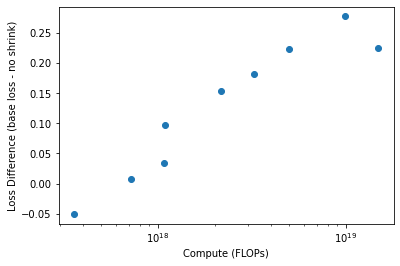

In [630]:
new_dict = dict()
for param, param_dict in loss_diff_map.items():
    for token, token_dict in param_dict.items():
        new_dict[6 * param * token * param] = token_dict

plt.clf()
plt.scatter(
    sorted(new_dict.keys()), 
    [new_dict[k] for k in sorted(new_dict.keys())], 
    marker='o'
)
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Loss Difference (base loss - no shrink)")
# plt.yscale("log")
plt.xscale("log")

In [631]:
# mapping the difference in loss between low shrink (0.2) and base loss
## for each target scale-tkpm, given the smallest base scale, 
## create a dict with the value as the loss difference between lambda=0.2 and BASE LOSS

loss_diff_map = {}

for _target in _targets:
    loss_diff_map[_target] = {}
    for _tkpm in _tkpms:
        _df = full_df.loc[
            (full_df.base_N == _base) & 
            (full_df.target_N == _target) & 
            (full_df.tkpm == _tkpm)
        ]
        if len(_df) == 0:
            continue
        _loss = _df.loc[_df.shrink == 0.2]["Validation Loss"].min()
        if pd.isna(_loss):
            continue
        loss_diff_map[_target][_tkpm] = BASE_LOSS - _loss

Text(0, 0.5, 'Loss Difference (base loss - 0.2 shrink)')

<Figure size 432x288 with 0 Axes>

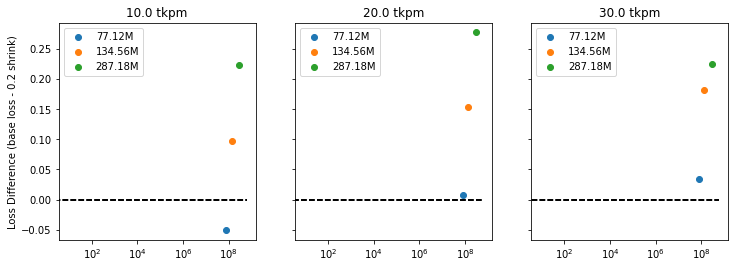

In [632]:
plt.clf()
fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False, sharey=True)
for i, k in enumerate(sorted(loss_diff_map.keys())):
    for j, tkpm in enumerate(sorted(loss_diff_map[k].keys())):
        ax = axes[0][j]
        ax.set_title(f"{tkpm} tkpm")
        ax.scatter(k, loss_diff_map[k][tkpm], label=f"{k/1e6:.2f}M")
        ax.legend(loc="upper left")
        axes[0, j].hlines(
            0, xmin=0, xmax=max(list(loss_diff_map.keys())), 
            colors='r', linestyles='dashed', color="black"
        )
        ax.set_xscale("log")
        # ax.set_xlim(1e7, 1e9)
        # ax.set_ylim(-0.001, 0.1)
        # ax.set_yscale("log")
axes[0, 0].set_ylabel("Loss Difference (base loss - 0.2 shrink)", fontsize=10)

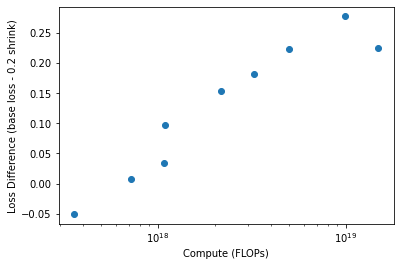

In [633]:
new_dict = dict()
for param, param_dict in loss_diff_map.items():
    for token, token_dict in param_dict.items():
        new_dict[6 * param * token * param] = token_dict

plt.clf()
plt.scatter(
    sorted(new_dict.keys()), 
    [new_dict[k] for k in sorted(new_dict.keys())], 
    marker='o'
)
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Loss Difference (base loss - 0.2 shrink)")
# plt.yscale("log")
plt.xscale("log")

---

## Fitting Laws

In [523]:
def huber_loss(params, data, y_true, delta=1e-3):
    """
    Huber loss
    """
    y_pred = functional_form(data, params)
    residuals = np.array(y_true) - np.array(y_pred)
    abs_residuals = np.abs(residuals)
    
    return np.sum(np.where(
        abs_residuals <= delta,
        0.5 * residuals**2,  # Quadratic part got <= delta
        delta * (abs_residuals - 0.5 * delta)  # Linear part, otherwise
    ))


def huber_loss_scipy(params, X, y_true, delta=1e-3):
    """
    Using scipy's built-in Huber function
    """
    y_pred = functional_form(X, params)
    residuals = np.array(y_true) - np.array(y_pred)    
    # scipy.special.huber returns the Huber function value
    # huber(delta, r) computes the Huber loss for residual r
    losses = huber(delta, residuals)
    
    return np.sum(losses)


def fit_model(
    X_data: list | np.ndarray, 
    y_data: list | np.ndarray, 
    initial_grid: list | np.ndarray, 
    delta: float=1e-3, 
    scipy: bool=True
) -> tuple[list[float], float]:
    """
    Fit using Huber loss (robust to outliers)
    """
    best_params = None
    best_loss = np.inf
    _loss = huber_loss_scipy if scipy else huber_loss
    for init in initial_grid:
        result = minimize(
                fun=_loss,
                x0=init,
                args=(X_data, y_data),
                method='L-BFGS-B',
                # options={'disp': True, 'maxiter': 100}
            )
        if result.fun < best_loss:
                best_loss = result.fun
                best_params = result.x
    
    return best_params, best_loss

In [524]:
def functional_form(
    data: list | np.ndarray,
    params: list[float]
) -> list[float]:
    """ The parameteric function 
    """
    # Ensure numpy array
    data = np.asarray(data)
    
    if data.ndim == 1:
        data = data.reshape(1, -1)
        squeeze_output = True
    else:
        squeeze_output = False

    L_base = data[:, 0]
    C = data[:, 1]
    lambda_shrink = data[:, 2]

    lambda_star = params[0]
    A, P, Q = params[1:4]
    alpha, gamma, delta = params[4:7]

    L = L_base - (
         A * np.log(C) ** alpha +
         P * (lambda_shrink - lambda_star) ** gamma +
        Q * C ** delta * (lambda_star - lambda_shrink)
    )    
    
    return L.squeeze() if squeeze_output else L


In [525]:
# initialization = list(itertools.product(
#     [0, 1.0e-4, 1.0e-2, 1.0e-1, 0.4, 1.0],  # lambda_star

#     [0, 5, 10, 15, 20, 25],  # A
#     [0, 5, 10, 15, 20, 25],  # P
#     [-1, -0.5, 0, 0.5, 1, 2],  # Q

#     [0, 0.5, 1.0, 1.5, 2.0, 3.0],  # alpha
#     [-0.5, 0, 0.5, 1.0, 1.5, 2.0],  # gamma
#     [-2.0, -0.1, 0, 0.5, 1.0, 2.0],  # delta
# ))

In [526]:
initialization = list(itertools.product(
    [0, 1.0e-4, 1.0e-2, 1.0e-1],  # lambda_star

    [0, 10],  # A
    [0, 10],  # P
    [-1, 0, 1],  # Q

    [ 0.5, 1.5],  # alpha
    [-0.5, 0.5],  # gamma
    [ -0.1, 0, 0.5],  # delta
))

In [527]:
new_df = full_df.copy()

new_df = new_df.loc[
    (new_df.base_N == _base)
].dropna().groupby(["target_N", "shrink", "tkpm"])["Validation Loss"].min()
# new_df["C"] = 6 * new_df.target_N * new_df.tkpm * new_df.target_N

new_df = new_df.reset_index()
new_df['C'] = 6 * new_df['target_N'] * new_df['tkpm'] * new_df['target_N']
new_df["base_loss"] = BASE_LOSS

# specific ordering
new_df = new_df[["base_loss", "C", "shrink", "Validation Loss"]]

display(new_df.head())

X_data = new_df[["base_loss", "C", "shrink"]].to_numpy()
y_data = new_df["Validation Loss"].to_numpy()

print(X_data.shape, y_data.shape)

,base_loss,C,shrink,Validation Loss
0,2.495616,6.248446e+16,0.0,2.259872
1,2.495616,1.249689e+17,0.0,2.175067
2,2.495616,1.874534e+17,0.0,2.150423
3,2.495616,6.248446e+16,0.2,2.252899
4,2.495616,1.249689e+17,0.2,2.176015


(70, 3) (70,)


In [528]:
%%capture

best_params, best_loss = fit_model(X_data, y_data, initialization)

# alpha, beta = best_params[:2]
# A, B = np.exp(best_params[2:4])
# E = np.exp(best_params[4])
# alpeta = alpha + beta

In [529]:
lambda_star = best_params[0]
A, P, Q = best_params[1:4]
alpha, gamma, delta = best_params[4:7]

TypeError: 'NoneType' object is not subscriptable

In [ ]:
lambda_star, best_loss


(np.float64(-1.6702270025967612), inf)

In [ ]:
A, P, Q

(np.float64(0.026318376568604356),
 np.float64(-2.7452627800420015),
 np.float64(1.2152945394467656))

In [ ]:
alpha, gamma, delta

(np.float64(1.3002629775050663),
 np.float64(-0.003235856861634231),
 np.float64(-0.09461315693272845))

---

## Collapse

In [11]:
def get_pareto_frontier(df, col_name="Validation Loss"): 
    """ Function to compute Pareto over FLOPs.
    """
    df_sorted = df.sort_values(by=["flops", col_name], ascending=[True, True])
    df_sorted = df_sorted.drop_duplicates(subset=["flops"], keep="first")
    pareto_points = []
    min_loss_so_far = float('inf')
    for _, row in df_sorted.iterrows():
        if row[col_name] < min_loss_so_far:
            pareto_points.append(row)
            min_loss_so_far = row[col_name]

    return pd.DataFrame(pareto_points)

In [174]:
# get curves to test collapse

x_col = "flops"
y_col = "Validation Loss"

### use muP as control
mup_df = full_df.loc[(full_df.shrink == 0.0)]
display(mup_df)

### use WS as test
_shrinking = 0.4
ws_df = full_df.loc[(full_df.shrink == _shrinking)]
display(ws_df)

tag,tokens,flops,Train Loss,Validation Loss,tkpm,base_N,target_N,shrink,width,depth,max_lr,warmup,cooldown,seed,method,train_loss_smoothed
2694594,0,0.000000e+00,10.844599,10.852564,10.0,14562560,32270848,0.0,256,8,0.0030,0.01,0.2,666,mup,5.469055
2694595,65536,1.268941e+13,10.842909,NaN,10.0,14562560,32270848,0.0,256,8,0.0030,0.01,0.2,666,mup,5.468432
2694596,131072,2.537883e+13,10.453922,NaN,10.0,14562560,32270848,0.0,256,8,0.0030,0.01,0.2,666,mup,5.467185
2694597,196608,3.806824e+13,10.039717,NaN,10.0,14562560,32270848,0.0,256,8,0.0030,0.01,0.2,666,mup,5.465315
2694598,262144,5.075766e+13,9.393600,NaN,10.0,14562560,32270848,0.0,256,8,0.0030,0.01,0.2,666,mup,5.462826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3011752,8612610048,1.484039e+19,1.583426,NaN,30.0,77124608,287183360,0.0,1280,8,0.0025,0.01,0.2,666,mup,1.606442
3011753,8613126144,1.484128e+19,1.611248,1.616685,30.0,77124608,287183360,0.0,1280,8,0.0025,0.01,0.2,666,mup,1.606440
3011754,8613642240,1.484217e+19,1.559605,NaN,30.0,77124608,287183360,0.0,1280,8,0.0025,0.01,0.2,666,mup,1.606438
3011755,8614158336,1.484306e+19,1.615020,NaN,30.0,77124608,287183360,0.0,1280,8,0.0025,0.01,0.2,666,mup,1.606438


tag,tokens,flops,Train Loss,Validation Loss,tkpm,base_N,target_N,shrink,width,depth,max_lr,warmup,cooldown,seed,method,train_loss_smoothed
4924,0,0.000000e+00,9.508313,9.486343,10.0,14562560,32270848,0.4,256,8,0.0030,0.01,0.2,666,warmstart,4.222024
4925,65536,1.268941e+13,9.478653,NaN,10.0,14562560,32270848,0.4,256,8,0.0030,0.01,0.2,666,warmstart,4.221680
4926,131072,2.537883e+13,8.954137,NaN,10.0,14562560,32270848,0.4,256,8,0.0030,0.01,0.2,666,warmstart,4.220992
4927,196608,3.806824e+13,7.887499,NaN,10.0,14562560,32270848,0.4,256,8,0.0030,0.01,0.2,666,warmstart,4.219961
4928,262144,5.075766e+13,6.921789,NaN,10.0,14562560,32270848,0.4,256,8,0.0030,0.01,0.2,666,warmstart,4.218589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2644510,8612610048,1.484039e+19,1.632039,NaN,30.0,77124608,287183360,0.4,1280,8,0.0025,0.01,0.2,666,warmstart,1.594130
2644511,8613126144,1.484128e+19,1.609459,1.616442,30.0,77124608,287183360,0.4,1280,8,0.0025,0.01,0.2,666,warmstart,1.594130
2644512,8613642240,1.484217e+19,1.550647,NaN,30.0,77124608,287183360,0.4,1280,8,0.0025,0.01,0.2,666,warmstart,1.594130
2644513,8614158336,1.484306e+19,1.613962,NaN,30.0,77124608,287183360,0.4,1280,8,0.0025,0.01,0.2,666,warmstart,1.594130


Text(0.5, 0, 'Parameters')

<Figure size 640x480 with 0 Axes>

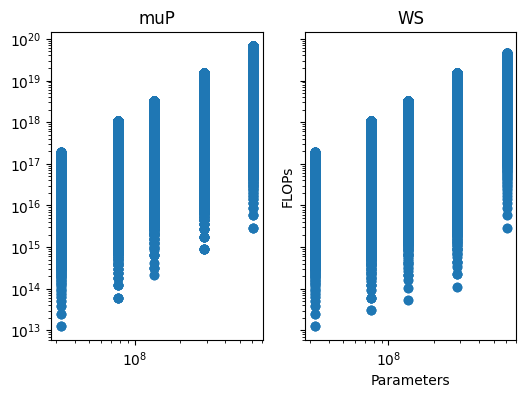

In [13]:
plt.clf()

fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharex=True, sharey=True)

axes[0].scatter(mup_df.target_N, mup_df.flops)
axes[0].set_title("muP")

axes[1].scatter(ws_df.target_N, ws_df.flops)
axes[1].set_title("WS")

plt.xscale("log")
plt.yscale("log")
plt.ylabel("FLOPs")
plt.xlabel("Parameters")

In [72]:
# grouping LCs

_bases = mup_df.base_N.unique().tolist()
_target = mup_df.target_N.unique().tolist()
_tkpm = mup_df.tkpm.unique().tolist()

mup_lcs = {}
ws_lcs = {}
for _base in _bases:
    for _target in _targets:
        for _tkpm in _tkpms:
            key = (_base, _target, _tkpm)
            mup_df_slice = mup_df.loc[
                (mup_df.base_N == _base) & 
                (mup_df.target_N == _target) & 
                (mup_df.tkpm == _tkpm)
            ]
            mup_df_slice = mup_df_slice.loc[mup_df_slice[y_col].dropna().index]
            if not len(mup_df_slice) == 0:
                mup_lcs[key] = mup_df_slice[[x_col, y_col]]

            ws_df_slice = ws_df.loc[
                (ws_df.base_N == _base) & 
                (ws_df.target_N == _target) & 
                (ws_df.tkpm == _tkpm)
            ]
            ws_df_slice = ws_df_slice.loc[ws_df_slice[y_col].dropna().index]
            if not len(ws_df_slice) == 0:
                ws_lcs[key] = ws_df_slice[[x_col, y_col]]

# getting Pareto

mup_pareto = []
for k, v in mup_lcs.items():
    _df = v.sort_values(by=x_col)
    mup_pareto.append(_df.iloc[-1].values.tolist())
mup_pareto = pd.DataFrame(mup_pareto, columns=[x_col, y_col])
mup_pareto = get_pareto_frontier(mup_pareto)

ws_pareto = []
for k, v in ws_lcs.items():
    _df = v.sort_values(by=x_col)
    ws_pareto.append(_df.iloc[-1].values.tolist())
ws_pareto = pd.DataFrame(ws_pareto, columns=[x_col, y_col])
ws_pareto = get_pareto_frontier(ws_pareto)


In [63]:
mup_pareto = mup_pareto.iloc[1:]
ws_pareto = ws_pareto.iloc[1:]

<Figure size 640x480 with 0 Axes>

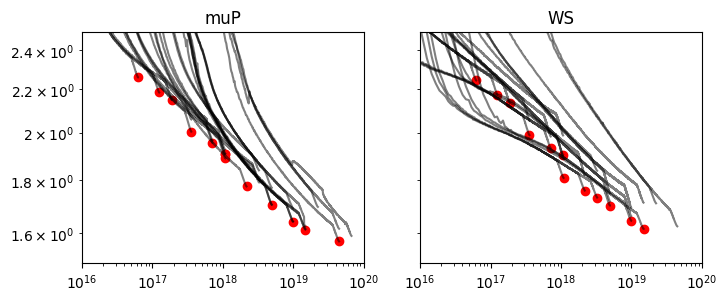

In [73]:
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)

axes[0].set_title("muP")
for k, v in mup_lcs.items():
    _df = v
    axes[0].plot(_df[x_col], _df[y_col], alpha=0.5, color="black")
axes[0].scatter(mup_pareto[x_col], mup_pareto[y_col], color="red", label="muP Pareto")

axes[1].set_title("WS")
for k, v in ws_lcs.items():
    _df = v
    axes[1].plot(_df[x_col], _df[y_col], alpha=0.5, color="black")
axes[1].scatter(ws_pareto[x_col], ws_pareto[y_col], color="red", label="muP Pareto")

plt.ylim(1.5, 2.5)
plt.xlim(1e16, 1e20)
plt.yscale("log")
plt.xscale("log")

In [16]:
 from scaling.utils import (
    get_pareto_frontier, 
    get_final_points_from_curve_set, 
    fit_linear_model,
    functional_form_chin3,
    fit_parametric_form,
)

In [157]:
_flops = np.logspace(15, 25, num=20)
C_min = _flops.min()

In [114]:
# fitting some straight-forward model

mup_slope, mup_intercept, mup_residual, _, _ = fit_linear_model(mup_pareto[x_col] / C_min, mup_pareto[y_col])
print("muP:", mup_slope, mup_intercept, mup_residual ** 2)
ws_slope, ws_intercept, ws_residual, _, _ = fit_linear_model(ws_pareto[x_col] / C_min, ws_pareto[y_col])
print("WS:", ws_slope, ws_intercept, ws_residual ** 2)

muP: -0.060215555901509774 1.0623745384207384 0.981922514893659
WS: -0.06344381031153372 1.0718730970743438 0.9780022166152008


Text(0.5, 0.98, 'Approach 1 Fit')

<Figure size 640x480 with 0 Axes>

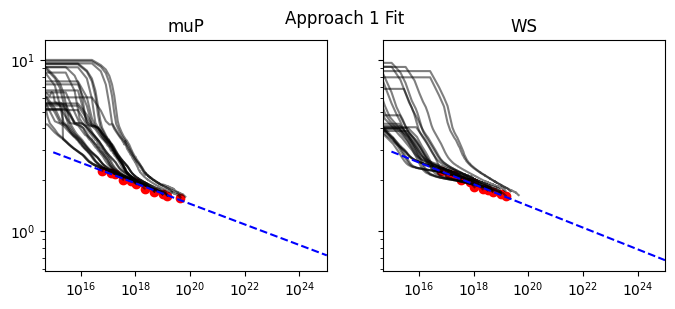

In [115]:
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)

axes[0].set_title("muP")
for k, v in mup_lcs.items():
    _df = v
    axes[0].plot(_df[x_col], _df[y_col], alpha=0.5, color="black")
axes[0].scatter(mup_pareto[x_col], mup_pareto[y_col], color="red", label="muP Pareto")
axes[0].plot(
    _flops, 
    np.exp(mup_intercept) * ((_flops / C_min) ** mup_slope), 
    color="blue", linestyle="dashed", label="muP Fit"
)

axes[1].set_title("WS")
for k, v in ws_lcs.items():
    _df = v
    axes[1].plot(_df[x_col], _df[y_col], alpha=0.5, color="black")
axes[1].scatter(ws_pareto[x_col], ws_pareto[y_col], color="red", label="muP Pareto")
axes[1].plot(
    _flops, 
    np.exp(ws_intercept) * ((_flops / C_min) ** ws_slope), 
    color="blue", linestyle="dashed", label="WS Fit"
)

# plt.ylim(1.5, 2.5)
plt.xlim(_flops.min() * 0.5, _flops.max())
plt.yscale("log")
plt.xscale("log")
plt.suptitle("Approach 1 Fit")

In [123]:
from typing import Callable, Tuple
from functools import partial
import numpy as np
import pandas as pd
import scipy
from typing import Callable, Dict, List, Tuple


def huber_loss(
    func_form: Callable,
    params: List | Dict,
    data: List | Dict,
    y_true: List,
    delta: float=1e-3,
) -> float:
    """ Compute the Huber loss between true and predicted values.

    Args:
        func_form (Callable): The functional form to generate predictions.
            Function that takes in data and parameters and returns predicted values.
        params (List | Dict): Parameters for the functional form.
        data (List | Dict): Input data for predictions.
        y_true (List): True target values.
        delta (float, optional): The threshold parameter for Huber loss. Defaults to 1e-3.
    
    Returns:
        float: The computed Huber loss.
    """
    y_pred = func_form(data, params)
    residuals = np.array(y_true) - np.array(y_pred)
    abs_residuals = np.abs(residuals)
    
    return np.sum(np.where(
        abs_residuals <= delta,
        0.5 * residuals ** 2,  # Quadratic part got <= delta
        delta * (abs_residuals - 0.5 * delta)  # Linear part, otherwise
    ))


def huber_loss_scipy(
    params: List | Dict,
    data: List | Dict,
    y_true: List,
    delta: float=1e-3,
    func_form: Callable=None,
    ylog: bool=False,
) -> float:
    """ Compute the Huber loss using SciPy.

    Args:
        func_form (Callable): The functional form to generate predictions.
            Function that takes in data and parameters and returns predicted values.
        params (List | Dict): Parameters for the functional form.
        data (List | Dict): Input data for predictions.
        y_true (List): True target values.
        delta (float, optional): The threshold parameter for Huber loss. Defaults to 1e-3.
    
    Returns:
        float: The computed Huber loss.
    """
    assert func_form is not None, "func_form must be provided for huber_loss_scipy."
    y_pred = func_form(data, params)
    residuals = (
        np.log(np.array(y_true)) - np.log(np.array(y_pred))
        if ylog else np.array(y_true) - np.array(y_pred) 
    )
    # scipy.special.huber returns the Huber function value
    # huber(delta, r) computes the Huber loss for residual r
    losses = scipy.special.huber(delta, residuals)
    
    return np.sum(losses)


def functional_form_L0(
    data: list | np.ndarray,
    params: list[float],
    xlog: bool=False,
) -> list[float]:
    """ The parameteric function 
    """
    assert len(params) == 3, "Expected 3 parameters for functional form."
    L0, a, b  = params
    assert len(data.shape)== 1, "Expected data with 1 column (C)."
    # N, D = data[:, 0], data[:, 1]
    C = data

    if xlog:
        C = np.log(C)

    # L = np.exp(a - alpha * np.log(N)) + np.exp(b - beta * np.log(D)) + np.exp(e)
    L = L0 + a * (C ** b)
    return L


def fit_parametric_form(
    func_form: Callable,
    X_data: list | np.ndarray,
    y_data: list | np.ndarray,
    initial_grid: list | np.ndarray,
    delta: float=1e-3,
    use_scipy: bool=True,
    xlog: bool=False,
    ylog: bool=False,
    bounds: list[float] | None=None,
) -> Tuple[float, float]:
    """
    Fit using Huber loss (robust to outliers)
    """
    best_params = None
    best_loss = np.inf
    _loss = partial(huber_loss_scipy, ylog=ylog) if use_scipy else huber_loss
    
    _loss = partial(_loss, func_form=partial(func_form, xlog=xlog), delta=delta)

    for init in initial_grid:
        result = scipy.optimize.minimize(
                fun=_loss,
                x0=init,
                args=(X_data, y_data),
                method='L-BFGS-B',
                bounds=bounds,
                # options={'disp': True, 'maxiter': 100}
            )
        if result.fun < best_loss:
                best_loss = result.fun
                best_params = result.x
    
    return best_params, best_loss


In [160]:
from itertools import product
_initial_grid = list(product(
    [0.5, 1.0, 1.5],  # L0
    [1e-2, 1e-1, 1, 10, 50, 100],  # a
    [-2, -1, -0.3, -0.1, -0.05],  # b
))

_bounds = None
_bounds = [
    (0.0, 3),  # L0
    (1e-5, 1000),  # a
    (-10, -5e-5),  # b
]

In [161]:
mup_params, mup_best_loss = fit_parametric_form(
    functional_form_L0,
    mup_pareto[x_col].to_numpy() / C_min,
    mup_pareto[y_col].to_numpy(),
    _initial_grid,
    bounds=_bounds,
    xlog=False,
    ylog=True,
)
print("muP params:", mup_params, "muP best loss:", mup_best_loss)

ws_params, ws_best_loss = fit_parametric_form(
    functional_form_L0,
    ws_pareto[x_col].to_numpy() / C_min,
    ws_pareto[y_col].to_numpy(),
    _initial_grid,
    bounds=_bounds,
    xlog=False,
    ylog=False,
)
print("WS params:", ws_params, "WS best loss:", ws_best_loss)

muP params: [ 0.78244086  2.37724955 -0.10932139] muP best loss: 0.0001297718870793124
WS params: [ 1.20967731  2.18395589 -0.17514672] WS best loss: 0.00025148362522861285


<Figure size 640x480 with 0 Axes>

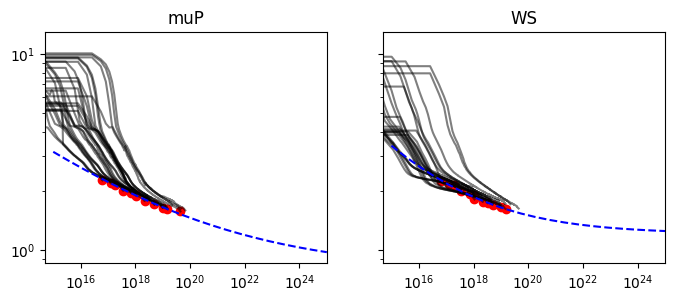

In [163]:
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)

# _flops = np.logspace(15, 21, num=20)

axes[0].set_title("muP")
for k, v in mup_lcs.items():
    _df = v
    axes[0].plot(_df[x_col], _df[y_col], alpha=0.5, color="black")
axes[0].scatter(mup_pareto[x_col], mup_pareto[y_col], color="red", label="muP Pareto")
axes[0].plot(
    _flops, 
    functional_form_L0(_flops / C_min, mup_params),
    color="blue", linestyle="dashed", label="muP Fit"
)

axes[1].set_title("WS")
for k, v in ws_lcs.items():
    _df = v
    axes[1].plot(_df[x_col], _df[y_col], alpha=0.5, color="black")
axes[1].scatter(ws_pareto[x_col], ws_pareto[y_col], color="red", label="muP Pareto")
axes[1].plot(
    _flops, 
    functional_form_L0(_flops / C_min, ws_params),
    color="blue", linestyle="dashed", label="WS Fit"
)

# plt.ylim(1.5, 2.5)
plt.xlim(_flops.min() * 0.5, _flops.max())
plt.yscale("log")
plt.xscale("log")
# plt.suptitle("Approach 3 Fit")

<Figure size 640x480 with 0 Axes>

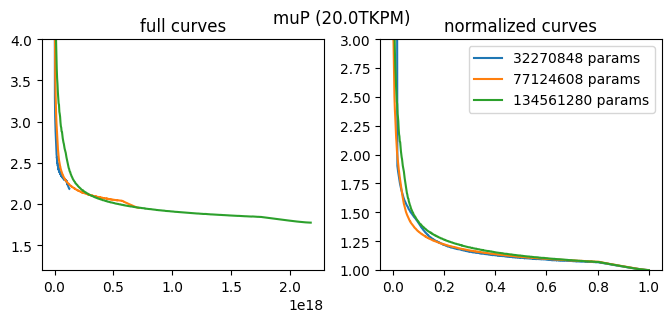

In [203]:
# testing collapse for g=2, mup

_base = mup_df.base_N.min()
_tkpm = 20.0

mup_g2 = mup_df.loc[np.round(mup_df.target_N / mup_df.base_N) == 2]

# _df = mup_df.loc[
#     (mup_df.base_N == _base) & 
#     (mup_df.tkpm == _tkpm)
# ]
_df = mup_g2[(mup_g2.tkpm == _tkpm)]
_df = _df.loc[_df[y_col].dropna().index]

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].set_title("full curves")
axes[1].set_title("normalized curves")
for _target in _df.target_N.unique().tolist():
    __df = _df.loc[_df.target_N == _target]
    axes[0].plot(__df[x_col], __df[y_col], label=f"{_target} params")
    axes[1].plot(
        __df[x_col] / __df[x_col].max(), 
        (__df[y_col] - mup_params[0]) / (__df[y_col].values[-1] - mup_params[0]), 
        label=f"{_target} params"
    )
axes[0].set_ylim(1.2, 4)
axes[1].set_ylim(1, 3)

plt.suptitle(f"muP ({_tkpm}TKPM)")
plt.legend();


<Figure size 640x480 with 0 Axes>

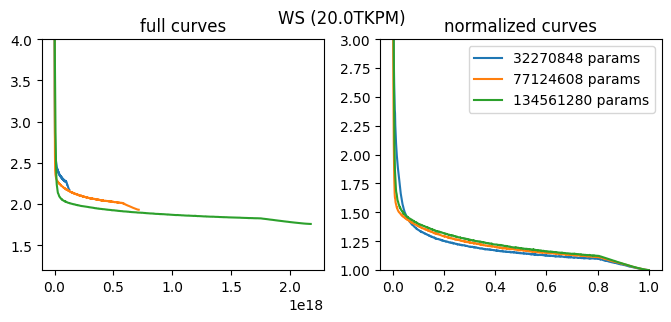

In [197]:
# testing collapse for g=2 WS

_base = ws_df.base_N.min()
_tkpm = 20.0

ws_g2 = ws_df.loc[np.round(ws_df.target_N / ws_df.base_N) == 2]

_df = ws_g2.loc[
    (ws_g2.tkpm == _tkpm) 
]
_df = _df.loc[_df[y_col].dropna().index]

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].set_title("full curves")
axes[1].set_title("normalized curves")
for _target in _df.target_N.unique().tolist():
    __df = _df.loc[_df.target_N == _target]
    axes[0].plot(__df[x_col], __df[y_col], label=f"{_target} params")
    axes[1].plot(
        __df[x_col] / __df[x_col].max(), 
        (__df[y_col] - ws_params[0]) / (__df[y_col].values[-1] - ws_params[0]), 
        label=f"{_target} params"
    )
axes[0].set_ylim(1.2, 4)
axes[1].set_ylim(1, 3)

plt.suptitle(f"WS ({_tkpm}TKPM)")
plt.legend();



<Figure size 640x480 with 0 Axes>

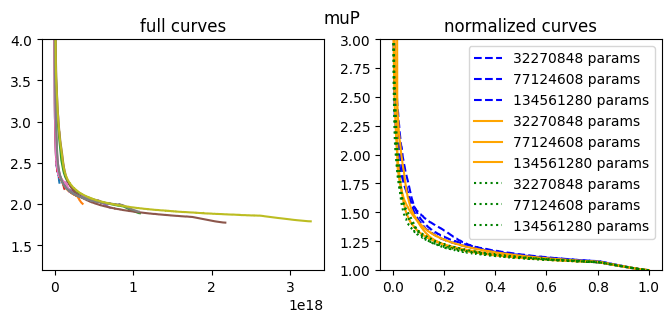

In [204]:
# testing collapse for g=2, mup

_base = mup_df.base_N.min()
_tkpm = 20.0

mup_g2 = mup_df.loc[np.round(mup_df.target_N / mup_df.base_N) == 2]

# _df = mup_df.loc[
#     (mup_df.base_N == _base) & 
#     (mup_df.tkpm == _tkpm)
# ]
_df = mup_g2  # [(mup_g2.tkpm == _tkpm)]
_df = _df.loc[_df[y_col].dropna().index]

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].set_title("full curves")
axes[1].set_title("normalized curves")
for _tkpm in _df.tkpm.unique().tolist():
    _color = {"10.0": "blue", "20.0": "orange", "30.0": "green"}.get(str(_tkpm), "black")
    for _target in _df.target_N.unique().tolist():
        _linestyle = {"10.0": "dashed", "20.0": "solid", "30.0": "dotted"}.get(str(_tkpm), "solid")
        __df = _df.loc[(_df.target_N == _target) & (_df.tkpm == _tkpm)]
        axes[0].plot(__df[x_col], __df[y_col], label=f"{_target} params")
        axes[1].plot(
            __df[x_col] / __df[x_col].max(), 
            (__df[y_col] - mup_params[0]) / (__df[y_col].values[-1] - mup_params[0]), 
            label=f"{_target} params",
            color=_color,
            linestyle=_linestyle
        )
axes[0].set_ylim(1.2, 4)
axes[1].set_ylim(1, 3)

plt.suptitle(f"muP")
plt.legend();


<Figure size 640x480 with 0 Axes>

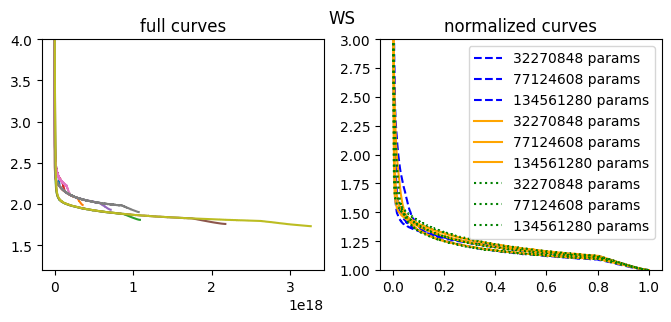

In [210]:
# testing collapse for g=2, WS

_base = mup_df.base_N.min()
_tkpm = 20.0

ws_g2 = ws_df.loc[np.round(ws_df.target_N / ws_df.base_N) == 2]

# _df = mup_df.loc[
#     (mup_df.base_N == _base) & 
#     (mup_df.tkpm == _tkpm)
# ]
_df = ws_g2  # [(mup_g2.tkpm == _tkpm)]
_df = _df.loc[_df[y_col].dropna().index]

plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].set_title("full curves")
axes[1].set_title("normalized curves")
for _tkpm in _df.tkpm.unique().tolist():
    _color = {"10.0": "blue", "20.0": "orange", "30.0": "green"}.get(str(_tkpm), "black")
    for _target in _df.target_N.unique().tolist():
        _linestyle = {"10.0": "dashed", "20.0": "solid", "30.0": "dotted"}.get(str(_tkpm), "solid")
        __df = _df.loc[(_df.target_N == _target) & (_df.tkpm == _tkpm)]
        axes[0].plot(__df[x_col], __df[y_col], label=f"{_target} params")
        axes[1].plot(
            __df[x_col] / __df[x_col].max(), 
            (__df[y_col] - ws_params[0]) / (__df[y_col].values[-1] - ws_params[0]), 
            label=f"{_target} params",
            color=_color,
            linestyle=_linestyle
        )
axes[0].set_ylim(1.2, 4)
axes[1].set_ylim(1, 3)

plt.suptitle(f"WS")
plt.legend();


---

In [ ]:
# taking all the data

## Step 1:
## subset for a lambda
## find the g showing up on Pareto

## Step 2:
## subset for a g
## find the lambdas showing up on Pareto


In [30]:
full_df.columns

Index(['tokens', 'flops', 'Train Loss', 'Validation Loss', 'tkpm', 'base_N',
       'target_N', 'shrink', 'width', 'depth', 'max_lr', 'warmup', 'cooldown',
       'seed', 'method', 'train_loss_smoothed'],
      dtype='object', name='tag')

In [80]:
case1 = full_df.loc[full_df.shrink == 0.4]
case1 = case1.loc[case1["Validation Loss"].dropna().index]
case1["g"] = case1.target_N / case1.base_N

case2 = full_df.loc[full_df.method == "net2net"]
case2 = case2.loc[case2["Validation Loss"].dropna().index]
case2["g"] = case2.target_N / case2.base_N

_g_lim = min(max(case1.g), max(case2.g))
case1 = case1.loc[case1.g <= _g_lim]
case2 = case2.loc[case2.g <= _g_lim]

final_points = {}
i = 0
for _base in sorted(case1.base_N.unique()):
    for _target in sorted(case1.target_N.unique()):
        for _tkpm in sorted(case1.tkpm.unique()):
            _df = case1.loc[
                (case1.base_N == _base) &
                (case1.target_N == _target) &
                (case1.tkpm == _tkpm)
            ]
            if len(_df) == 0:
                continue
            # print(_base, _target, _tkpm, _df.g.values[-1], _df.flops.values[-1], _df["Validation Loss"].values[-1])
            final_points.update({i: {
                "g": _df.g.values[-1], 
                "flops": _df.flops.values[-1], 
                "loss": _df["Validation Loss"].values[-1]
            }})
            i += 1
case1_df = pd.DataFrame.from_dict(final_points, orient="index").sort_values(by="flops")
case1_pareto = get_pareto_frontier(case1_df, y_name="loss")

final_points = {}
i = 0
for _base in sorted(case2.base_N.unique()):
    for _target in sorted(case2.target_N.unique()):
        for _tkpm in sorted(case2.tkpm.unique()):
            _df = case2.loc[
                (case2.base_N == _base) &
                (case2.target_N == _target) &
                (case2.tkpm == _tkpm)
            ]
            if len(_df) == 0:
                continue
            # print(_base, _target, _tkpm, _df.g.values[-1], _df.flops.values[-1], _df["Validation Loss"].values[-1])
            final_points.update({i: {
                "g": _df.g.values[-1], 
                "flops": _df.flops.values[-1], 
                "loss": _df["Validation Loss"].values[-1]
            }})
            i += 1
case2_df = pd.DataFrame.from_dict(final_points, orient="index").sort_values(by="flops")
case2_pareto = get_pareto_frontier(case2_df, y_name="loss")

Text(0.5, 1.05, 'g on Pareto Frontier for each method')

<Figure size 640x480 with 0 Axes>

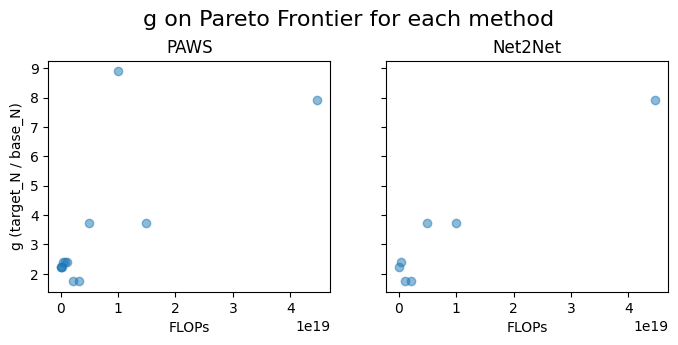

In [83]:
plt.clf()
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)
axes[0].set_title("PAWS")
axes[0].scatter(case1_pareto.flops, case1_pareto.g, marker="o", alpha=0.5)
axes[0].set_xlabel("FLOPs")
axes[0].set_ylabel("g (target_N / base_N)")

axes[1].set_title("Net2Net")
axes[1].scatter(case2_pareto.flops, case2_pareto.g, marker="o", alpha=0.5)
axes[1].set_xlabel("FLOPs")

# writing a common title with adequate whitespace over the subplot titles
plt.suptitle("g on Pareto Frontier for each method", y=1.05, fontsize=16)

In [64]:
case2 = full_df.loc[full_df.method == "net2net"]
case2 = case2.loc[case2["Validation Loss"].dropna().index]
case2["g"] = case2.target_N / case2.base_N

final_points = {}
i = 0
for _base in sorted(case2.base_N.unique()):
    for _target in sorted(case2.target_N.unique()):
        for _tkpm in sorted(case2.tkpm.unique()):
            _df = case2.loc[
                (case2.base_N == _base) &
                (case2.target_N == _target) &
                (case2.tkpm == _tkpm)
            ]
            if len(_df) == 0:
                continue
            # print(_base, _target, _tkpm, _df.g.values[-1], _df.flops.values[-1], _df["Validation Loss"].values[-1])
            final_points.update({i: {
                "g": _df.g.values[-1], 
                "flops": _df.flops.values[-1], 
                "loss": _df["Validation Loss"].values[-1]
            }})
            i += 1


In [65]:
final_df = pd.DataFrame.from_dict(final_points, orient="index").sort_values(by="flops")
final_df

,g,flops,loss
0,2.216015,6.246998e+16,2.291592
1,5.296089,3.568231e+17,2.072292
5,2.389916,3.568231e+17,2.023672
2,9.240221,1.086064e+18,2.002157
6,4.169747,1.086064e+18,1.948704
9,1.744726,1.086064e+18,1.924155
3,9.240221,2.172446e+18,1.901763
7,4.169747,2.172446e+18,1.869150
10,1.744726,2.172446e+18,1.852917
4,19.720664,4.947093e+18,1.784784


Text(0, 0.5, 'g (target_N / base_N)')

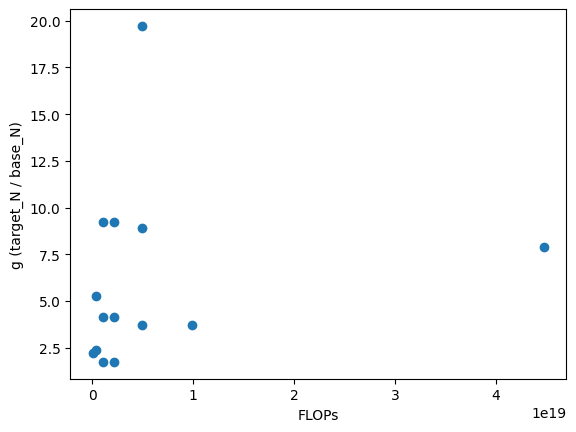

In [66]:
final_pareto_g = get_pareto_frontier(final_df, y_name="loss") 

plt.clf()
plt.scatter(final_df.flops, final_df.g, marker="o", )
plt.xlabel("FLOPs")
plt.ylabel("g (target_N / base_N)")

---

### ABLATIONS

In [115]:
ABLATION_BASE = Path("/work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/icml/n_heads")

In [109]:
# picked up from /work/dlclarge1/mallik-warmstarting/warmstarting_exps/results/icml/base
BASE_MODEL_VAL_LOSSES = {
    "s0": 4.922329425811768,
    "s1": 4.262894630432129,
    "s2": 3.7962307929992676,
    "s3": 1.9329144954681396,
}

In [110]:
BASELINE = "mup"

ZEROS = "warm_pad_zeros"
ZEROS_PERTURB = "warm_snp_zeros_with_mup_no_shrink"
ZEROS_SHRINK = "warm_snp_zeros_with_mup_no_perturb"
PAWS = "warm_snp_zeros_with_mup"

LABEL_MAP = {
    BASELINE: "Scratch",
    ZEROS: "Zeros",
    ZEROS_PERTURB: "Zeros+Perturb",
    ZEROS_SHRINK: "Zeros+Shrink",
    PAWS: "Shrink+Perturb",
}

In [111]:
# g<=5 scales
SCALES = [
    # "s1-s2",
    # "s1-s3",
    # "s2-s3",
    "s2-s4"
]

<Figure size 640x480 with 0 Axes>

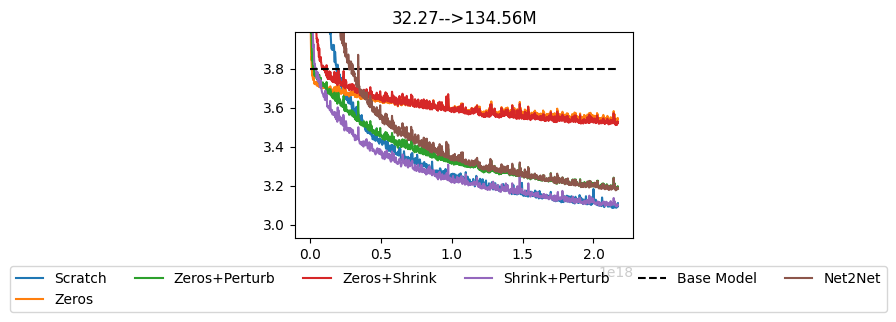

In [117]:
plt.clf()
fig, axes = plt.subplots(1, len(SCALES), figsize=(4*len(SCALES), 3))

for i, _scale in enumerate(SCALES):
    ax = axes if len(SCALES) == 1 else axes[i]
    _min_tracker = np.inf
    for _method in [BASELINE, ZEROS, ZEROS_PERTURB, ZEROS_SHRINK, PAWS]:
        _df = read_tb_parquet(ABLATION_BASE / _method / _scale / "seed=666" / "tb_logs.parquet")
        ax.plot(
            _df.loc[_df["Validation Loss"].dropna().index].flops,
            _df.loc[_df["Validation Loss"].dropna().index]["Validation Loss"],
            label=LABEL_MAP[_method]
        )
        _min_tracker = min(_min_tracker, _df.loc[_df["Validation Loss"].dropna().index]["Validation Loss"].min())
    ax.set_title(f"{PARAM_MAP[ _scale.split('-')[0]]/1e6:.2f}-->{PARAM_MAP[ _scale.split('-')[1]]/1e6:.2f}M")
    ax.hlines(
        BASE_MODEL_VAL_LOSSES[ _scale.split("-")[0]], 
        0, _df.flops.max(), 
        color="black", linestyle="--", label="Base Model")
    ax.set_ylim(_min_tracker * 0.95, BASE_MODEL_VAL_LOSSES[ _scale.split("-")[0] ] * 1.05)

# adding Net2Net
_df = read_tb_parquet(ABLATION_BASE / "warm_hyperclone" / "s2-s4" / "seed=666" / "tb_logs.parquet")
ax.plot(
    _df.loc[_df["Validation Loss"].dropna().index].flops,
    _df.loc[_df["Validation Loss"].dropna().index]["Validation Loss"],
    label="Net2Net",
)
_min_tracker = min(_min_tracker, _df.loc[_df["Validation Loss"].dropna().index]["Validation Loss"].min())
ax.set_ylim(_min_tracker * 0.95, BASE_MODEL_VAL_LOSSES[ _scale.split("-")[0] ] * 1.05)

handles, labels = axes[0].get_legend_handles_labels() if len(SCALES) > 1 else axes.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=len(LABEL_MAP)+1, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

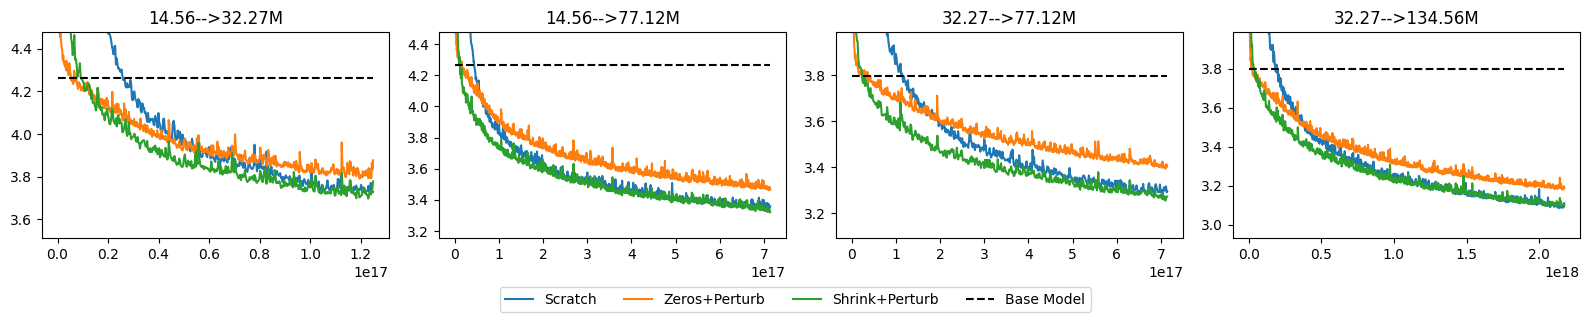

In [156]:


plt.clf()
fig, axes = plt.subplots(1, len(SCALES), figsize=(4*len(SCALES), 3))

for i, _scale in enumerate(SCALES):
    ax = axes[i]
    _min_tracker = np.inf
    for _method in [BASELINE, ZEROS_PERTURB, PAWS]:
        _df = read_tb_parquet(ABLATION_BASE / _method / _scale / "seed=666" / "tb_logs.parquet")
        ax.plot(
            _df.loc[_df["Validation Loss"].dropna().index].flops,
            _df.loc[_df["Validation Loss"].dropna().index]["Validation Loss"],
            label=LABEL_MAP[_method]
        )
        _min_tracker = min(_min_tracker, _df.loc[_df["Validation Loss"].dropna().index]["Validation Loss"].min())
    ax.set_title(f"{PARAM_MAP[ _scale.split('-')[0]]/1e6:.2f}-->{PARAM_MAP[ _scale.split('-')[1]]/1e6:.2f}M")
    ax.hlines(
        BASE_MODEL_VAL_LOSSES[ _scale.split("-")[0]], 
        0, _df.flops.max(), 
        color="black", linestyle="--", label="Base Model")
    ax.set_ylim(_min_tracker * 0.95, BASE_MODEL_VAL_LOSSES[ _scale.split("-")[0] ] * 1.05)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=len(LABEL_MAP)+1, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()